# Analítica 311 — Métricas Derivadas, Segmentación y Parámetros
## Cálculos analíticos para visualización en Tableau

**Input**: `outputs/week-04-311/` — modelo estrella (`fact_311` + dimensiones) del notebook anterior
**Objetivo**: definir métricas derivadas, al menos un segmento relevante y los parámetros/filtros analíticos que rigen el análisis, dejando todo documentado y exportado para conectar en Tableau sin reprocesamiento.

**Documento de referencia**: `docs/reglas-metricas-segmentos-parametros.md` explica, fuera del código, qué mide cada métrica, por qué se definió el segmento elegido y qué justifica cada parámetro.

---
## 0. Setup

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from _shared import ensure_output_dir, save_for_tableau_final

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

WEEK       = 'week-05-311'
INPUT_DIR  = ROOT / 'outputs' / 'week-04-311'
OUTPUT_DIR = ensure_output_dir(WEEK)

print(f'Input:  {INPUT_DIR}  →  existe: {INPUT_DIR.exists()}')
print(f'Output: {OUTPUT_DIR}')

Input:  C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-04-311  →  existe: True
Output: C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-05-311


---
## 1. Carga del modelo estrella

Leemos `fact_311` y las cuatro dimensiones exportadas por el notebook 03. Este notebook no vuelve a tocar el dataset crudo ni `311_clean.csv` — todo el cálculo parte de las fuentes ya modeladas, lo que garantiza que las métricas aquí definidas son consistentes con el modelo que ya está validado.

In [2]:
fact         = pd.read_csv(INPUT_DIR / 'fact_311.csv', parse_dates=['date'])
dim_fecha    = pd.read_csv(INPUT_DIR / 'dim_fecha.csv', parse_dates=['date'])
dim_geo      = pd.read_csv(INPUT_DIR / 'dim_geo.csv')
dim_agencia  = pd.read_csv(INPUT_DIR / 'dim_agencia.csv')
dim_problema = pd.read_csv(INPUT_DIR / 'dim_problema.csv')

fact['year'] = fact['date'].dt.year

print(f'fact_311:     {fact.shape}')
print(f'dim_fecha:    {dim_fecha.shape}')
print(f'dim_geo:      {dim_geo.shape}')
print(f'dim_agencia:  {dim_agencia.shape}')
print(f'dim_problema: {dim_problema.shape}')
fact.head(3)

fact_311:     (94500, 18)
dim_fecha:    (962, 7)
dim_geo:      (5, 2)
dim_agencia:  (16, 2)
dim_problema: (187, 3)


,Unique Key,date,Borough,Agency,Problem,Status,Open Data Channel Type,hour_of_day,resolution_hours,resolution_days,Latitude,Longitude,Incident Zip,Community Board,Council District,Police Precinct,problem_family,year
0,68669433,2026-04-14,Brooklyn,NYPD,Illegal Parking,CLOSED,MOBILE,5,5.081389,0.211725,40.616921,-74.032987,11209.0,10 BROOKLYN,47.0,Precinct 68,Tráfico / Estacionamiento,2026
1,68689064,2026-04-16,Queens,NYC311-PRD,Street Condition,CLOSED,UNKNOWN,8,5.025556,0.209398,40.762760,-73.904837,11377.0,01 QUEENS,22.0,Precinct 114,Infraestructura vial,2026
2,68687035,2026-04-17,Brooklyn,NYPD,Illegal Parking,IN PROGRESS,ONLINE,0,NaN,NaN,40.643372,-73.888039,11236.0,18 BROOKLYN,46.0,Precinct 69,Tráfico / Estacionamiento,2026


---
## 2. Parámetros analíticos

Esta sección define explícitamente los parámetros que controlan el resto del notebook. Cambiarlos aquí re-calcula automáticamente el segmento y las métricas — son el único lugar donde se "decide" el alcance del análisis.

### 2.1 Parámetro — rango de años de análisis

Antes de fijar el parámetro, miramos cuántas solicitudes hay por año en el dataset completo.

In [3]:
dist_anual = fact['year'].value_counts().sort_index()
print('Solicitudes por año (dataset completo):')
print(dist_anual)
print()
print(f"Rango de fechas: {fact['date'].min().date()}  →  {fact['date'].max().date()}")

Solicitudes por año (dataset completo):
year
2023    11519
2024    34573
2025    36549
2026    11859
Name: count, dtype: int64

Rango de fechas: 2023-08-30  →  2026-04-17


**Decisión**: `ANIO_INICIO = 2024`, `ANIO_FIN = 2025`.

**Por qué**: 2023 solo tiene datos desde agosto (~4 meses) y 2026 solo hasta abril (~4 meses) — son años parciales por construcción de la muestra, no por un patrón real de demanda. Compararlos contra años completos (2024, 2025) en una métrica de variación interanual produciría una conclusión falsa (ej. "las solicitudes cayeron en 2026" cuando en realidad solo faltan 8 meses de datos).

**Alternativa descartada**: usar todo el rango 2023-2026 sin filtrar. Se descartó porque las métricas de volumen y variación interanual quedarían contaminadas por la incompletitud de los años extremos — el principio es el mismo que llevó a usar mediana en lugar de media (no dejar que un artefacto de la muestra se interprete como señal).

**Cómo reusar el parámetro**: el segmento (sección 3) y las métricas derivadas (sección 4) se calculan sobre `fact_periodo`, que es el resultado de aplicar este filtro. Para repetir el análisis con otro rango basta con cambiar `ANIO_INICIO`/`ANIO_FIN` y re-ejecutar desde aquí.

In [4]:
# ── Parámetro 1: rango temporal de análisis ────────────────────────────────
ANIO_INICIO = 2024
ANIO_FIN    = 2025

fact_periodo = fact[
    (fact['year'] >= ANIO_INICIO) &
    (fact['year'] <= ANIO_FIN) &
    fact['Borough'].notna()
].copy()

print(f'Filas en fact_311 (completo):              {len(fact):>7,}')
print(f'Filas sin Borough (excluidas, FK inválida): {fact["Borough"].isna().sum():>7,}')
print(f'Filas en fact_periodo ({ANIO_INICIO}-{ANIO_FIN}):           {len(fact_periodo):>7,}')
print(f'% del total retenido:                       {len(fact_periodo) / len(fact) * 100:>6.1f}%')

Filas en fact_311 (completo):               94,500
Filas sin Borough (excluidas, FK inválida):     106
Filas en fact_periodo (2024-2025):            71,064
% del total retenido:                         75.2%


### 2.2 Parámetro — umbrales de cumplimiento de resolución (SLA)

**Decisión**: `UMBRALES_SLA_HORAS = [24, 72]` (1 día y 3 días).

**Por qué dos umbrales y no uno**: 24h responde "¿se resuelve en el mismo día?" — un estándar exigente, razonable para problemas que afectan la vía pública (tráfico, ruido). 72h responde "¿se resuelve en menos de un fin de semana largo?" — un estándar más realista para agencias con procesos administrativos (inspecciones, permisos). Reportar ambos evita elegir un único umbral arbitrario que favorezca o penalice artificialmente a ciertas familias de problema.

**Alternativa descartada**: usar la media de `resolution_hours` como umbral dinámico por familia. Se descartó por la misma razón documentada en `docs/decisiones-analiticas.md` (D3): la distribución de tiempos de resolución está fuertemente sesgada y la media no es representativa — un umbral basado en ella heredaría ese sesgo.

In [5]:
# ── Parámetro 2: umbrales de cumplimiento (SLA) de resolución ──────────────
UMBRALES_SLA_HORAS = [24, 72]  # 1 día y 3 días

print(f'Umbrales SLA configurados: {UMBRALES_SLA_HORAS} horas')
print(f'Mediana global de resolución en el periodo: {fact_periodo["resolution_hours"].median():.1f} h')
print(f'Solicitudes con resolución registrada:      {fact_periodo["resolution_hours"].notna().sum():,} de {len(fact_periodo):,}')

Umbrales SLA configurados: [24, 72] horas
Mediana global de resolución en el periodo: 7.1 h
Solicitudes con resolución registrada:      69,623 de 71,064


### 2.3 Referencia externa — población por borough

**Decisión**: incorporar la población de cada borough (Censo de EE. UU. 2020) como referencia fija para normalizar el volumen de solicitudes.

**Por qué**: el volumen absoluto de solicitudes está dominado por el tamaño del borough — Brooklyn y Queens tienen más solicitudes simplemente porque tienen más habitantes, no necesariamente porque tengan más problemas por persona. Normalizar por población (`tasa_por_10k_hab`) permite comparar boroughs en igualdad de condiciones.

**Por qué un valor fijo y no calculado del dataset**: la población no es una variable observable en 311 — es un dato de contexto externo. Se documenta como constante con su fuente para que la normalización sea auditable y reproducible.

In [6]:
# ── Referencia externa: población por borough (Censo EE. UU. 2020) ─────────
POBLACION_BOROUGH = {
    'Bronx':         1_472_654,
    'Brooklyn':      2_736_074,
    'Manhattan':     1_694_251,
    'Queens':        2_405_464,
    'Staten Island':   495_747,
}

pd.Series(POBLACION_BOROUGH, name='poblacion').to_frame()

,poblacion
Bronx,1472654
Brooklyn,2736074
Manhattan,1694251
Queens,2405464
Staten Island,495747


---
## 3. Segmento: familia de problema × Borough

**Segmento elegido**: cruce entre `problem_family` (11 familias temáticas del notebook 03) y `Borough` (5 boroughs).

**Por qué este segmento y no otro**: responde directamente a "¿qué tipo de problema predomina en cada zona de la ciudad?" — la pregunta central de un dashboard de servicio ciudadano. Otros segmentos posibles (ej. canal de reporte × agencia) describen *cómo* se reporta, no *qué* ni *dónde*, y son menos relevantes para priorización de recursos.

Para cada combinación calculamos tres vistas de la misma cifra:
- `n_solicitudes`: volumen absoluto
- `pct_share_borough`: participación de esa familia dentro del borough (suma 100% por borough)
- `tasa_por_10k_hab`: volumen normalizado por población — comparable entre boroughs

In [7]:
seg_familia_borough = (
    fact_periodo
    .groupby(['Borough', 'problem_family'])
    .agg(n_solicitudes=('Unique Key', 'count'))
    .reset_index()
)

total_borough = seg_familia_borough.groupby('Borough')['n_solicitudes'].transform('sum')
seg_familia_borough['pct_share_borough'] = (seg_familia_borough['n_solicitudes'] / total_borough * 100).round(2)
seg_familia_borough['tasa_por_10k_hab'] = (
    seg_familia_borough['n_solicitudes'] / seg_familia_borough['Borough'].map(POBLACION_BOROUGH) * 10_000
).round(2)

print(f'seg_familia_borough: {seg_familia_borough.shape}')
seg_familia_borough.sort_values(['Borough', 'n_solicitudes'], ascending=[True, False]).head(10)

seg_familia_borough: (50, 5)


,Borough,problem_family,n_solicitudes,pct_share_borough,tasa_por_10k_hab
6,Bronx,Ruido,4991,31.82,33.89
4,Bronx,Otros,4958,31.61,33.67
8,Bronx,Tráfico / Estacionamiento,2106,13.43,14.30
1,Bronx,Calefacción / Agua Caliente,2042,13.02,13.87
0,Bronx,Agua / Alcantarillado,709,4.52,4.81
3,Bronx,Infraestructura vial,377,2.40,2.56
7,Bronx,Saneamiento,218,1.39,1.48
9,Bronx,Árboles / Parques,145,0.92,0.98
5,Bronx,Plagas / Roedores,106,0.68,0.72
2,Bronx,Graffiti,31,0.20,0.21


### 3.1 Familia dominante por borough

`problem_family` incluye `'Otros'`, la categoría residual de 138 tipos de problema (ver `docs/decisiones-analiticas.md`, D7). Como suele ser la más numerosa en casi todos los boroughs, reportamos dos vistas: con `'Otros'` (volumen real) y sin `'Otros'` (la familia temática *interpretable* más frecuente — más útil para priorizar).

In [8]:
cols = ['Borough', 'problem_family', 'n_solicitudes', 'pct_share_borough', 'tasa_por_10k_hab']

top_familia = (
    seg_familia_borough.sort_values('pct_share_borough', ascending=False)
    .groupby('Borough').head(1)
    .sort_values('Borough')
)
print('Familia dominante por borough (incluye "Otros"):')
print(top_familia[cols].to_string(index=False))

metric_familia_dominante = (
    seg_familia_borough[seg_familia_borough['problem_family'] != 'Otros']
    .sort_values('pct_share_borough', ascending=False)
    .groupby('Borough').head(1)
    .reset_index(drop=True)
    .sort_values('Borough')
)
print('\nFamilia dominante por borough (excluyendo "Otros" — interpretable):')
print(metric_familia_dominante[cols].to_string(index=False))

Familia dominante por borough (incluye "Otros"):
      Borough problem_family  n_solicitudes  pct_share_borough  tasa_por_10k_hab
        Bronx          Ruido           4991              31.82             33.89
     Brooklyn          Otros           7072              33.44             25.85
    Manhattan          Otros           6187              43.00             36.52
       Queens          Otros           5640              32.94             23.45
Staten Island          Otros           1042              38.22             21.02

Familia dominante por borough (excluyendo "Otros" — interpretable):
      Borough            problem_family  n_solicitudes  pct_share_borough  tasa_por_10k_hab
        Bronx                     Ruido           4991              31.82             33.89
     Brooklyn Tráfico / Estacionamiento           5373              25.41             19.64
    Manhattan                     Ruido           3613              25.11             21.33
       Queens Tráfico / Esta

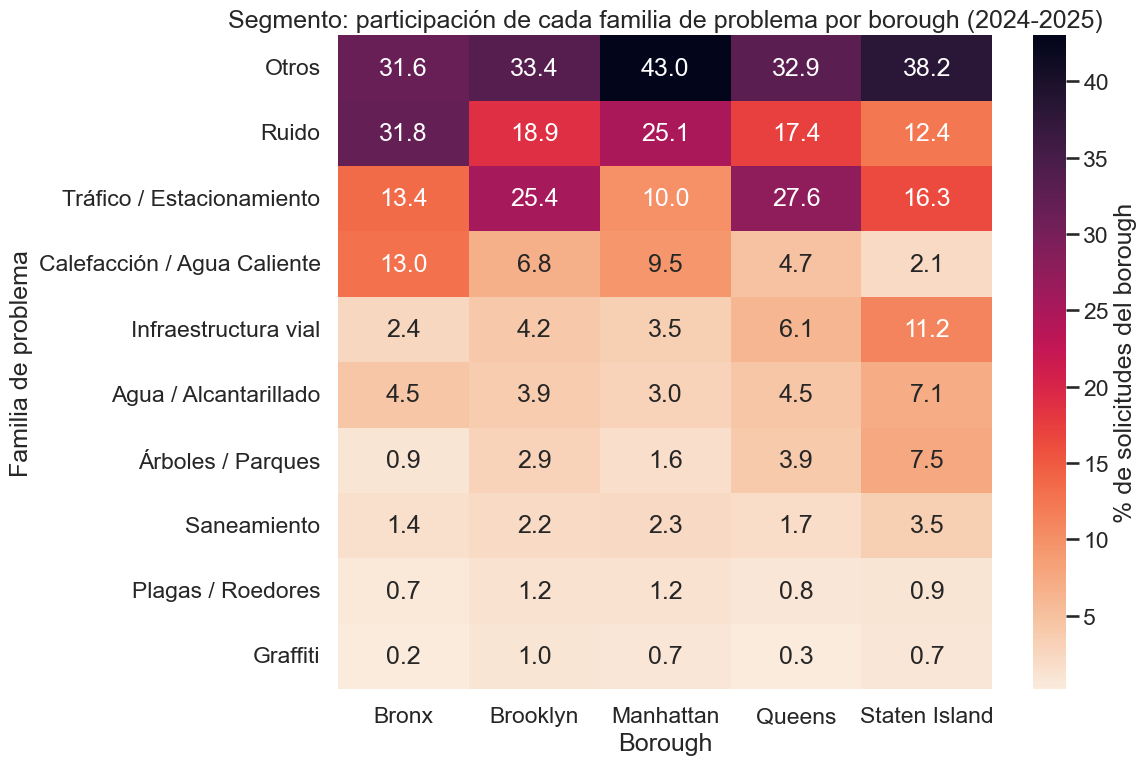

In [9]:
pivot = seg_familia_borough.pivot(index='problem_family', columns='Borough', values='pct_share_borough').fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='rocket_r',
            cbar_kws={'label': '% de solicitudes del borough'}, ax=ax)
ax.set_title(f'Segmento: participación de cada familia de problema por borough ({ANIO_INICIO}-{ANIO_FIN})')
ax.set_xlabel('Borough')
ax.set_ylabel('Familia de problema')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'heatmap_segmento_familia_borough.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Métricas derivadas

Dos métricas nuevas respecto al notebook 03, calculadas sobre `fact_periodo` (el dataset ya filtrado por el parámetro de rango temporal).

### 4.1 Cumplimiento de resolución por familia de problema

**Métrica**: `pct_dentro_24h` y `pct_dentro_72h` = porcentaje de solicitudes *resueltas* (con `resolution_hours` no nulo) cuyo tiempo de resolución está por debajo de cada umbral definido en el parámetro `UMBRALES_SLA_HORAS`.

**Qué pregunta responde**: ¿qué tipos de problema se resuelven rápido y cuáles se acumulan? Complementa la mediana de resolución por agencia del notebook 03 (que agrupa por *quién* resuelve) con una vista por *qué tipo de problema* se resuelve — más útil para un dashboard orientado al ciudadano, que reporta un `Problem`, no una `Agency`.

In [10]:
resueltos = fact_periodo[fact_periodo['resolution_hours'].notna()]

rows = []
for fam, g in resueltos.groupby('problem_family'):
    row = {'problem_family': fam, 'n_resueltos': len(g)}
    for h in UMBRALES_SLA_HORAS:
        row[f'pct_dentro_{h}h'] = round((g['resolution_hours'] <= h).mean() * 100, 1)
    rows.append(row)

metric_sla_resolucion = pd.DataFrame(rows).sort_values('pct_dentro_24h', ascending=False).reset_index(drop=True)
metric_sla_resolucion

,problem_family,n_resueltos,pct_dentro_24h,pct_dentro_72h
0,Tráfico / Estacionamiento,14075,98.9,99.9
1,Ruido,15744,91.7,94.7
2,Plagas / Roedores,698,75.9,86.1
3,Agua / Alcantarillado,2875,51.4,64.5
4,Saneamiento,1385,48.7,83.1
5,Otros,24218,36.4,51.9
6,Calefacción / Agua Caliente,5693,29.7,86.1
7,Infraestructura vial,2951,28.2,48.1
8,Árboles / Parques,1582,27.7,38.1
9,Graffiti,402,18.9,26.4


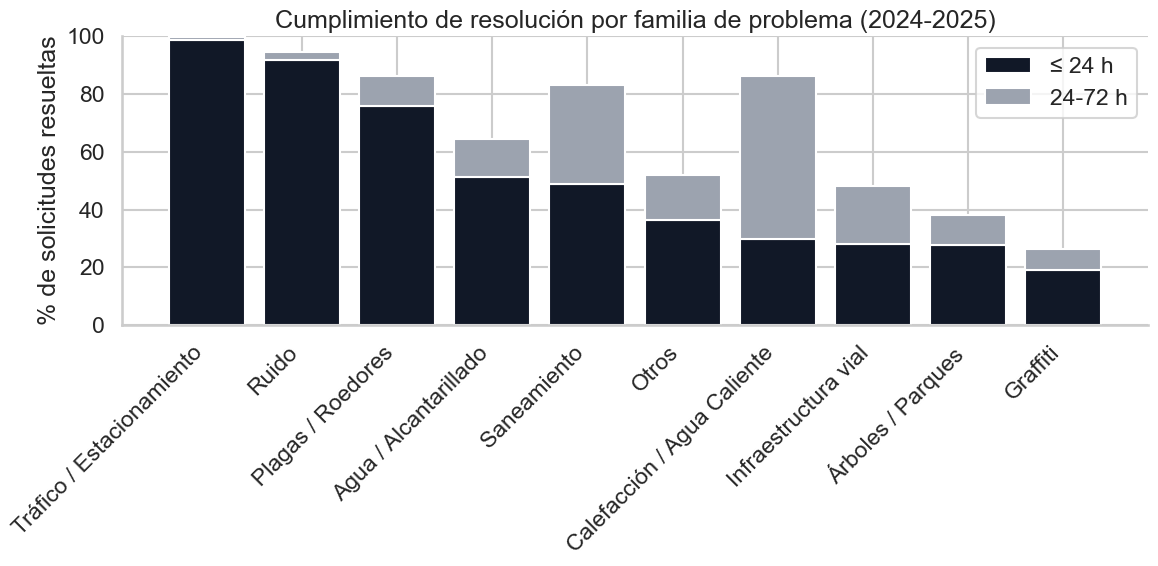

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
familias = metric_sla_resolucion['problem_family']

ax.bar(familias, metric_sla_resolucion['pct_dentro_24h'], label='≤ 24 h', color='#111827')
ax.bar(familias, metric_sla_resolucion['pct_dentro_72h'] - metric_sla_resolucion['pct_dentro_24h'],
       bottom=metric_sla_resolucion['pct_dentro_24h'], label='24-72 h', color='#9CA3AF')

ax.set_ylabel('% de solicitudes resueltas')
ax.set_title(f'Cumplimiento de resolución por familia de problema ({ANIO_INICIO}-{ANIO_FIN})')
ax.set_ylim(0, 100)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sla_resolucion_familia.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Variación interanual del volumen por borough

**Métrica**: `variacion_pct` = `(n_solicitudes_{ANIO_FIN} - n_solicitudes_{ANIO_INICIO}) / n_solicitudes_{ANIO_INICIO} * 100`, calculada por borough.

**Qué pregunta responde**: ¿la demanda de servicios 311 está creciendo, cayendo o estable en cada zona? Es la versión "interanual" de `agg_borough_year` del notebook 03 — ahí se exportó el volumen por año; aquí se deriva la tasa de cambio, que es lo que efectivamente se visualiza (una serie de cifras absolutas por año no comunica tendencia sin esta transformación).

**Por qué solo 2024→2025**: es la única comparación entre dos años completos disponible en el dataset (consistente con el parámetro de la sección 2.1).

In [12]:
vol_anual = (
    fact_periodo.groupby(['Borough', 'year'])
    .agg(n_solicitudes=('Unique Key', 'count'))
    .reset_index()
)

metric_variacion_anual = vol_anual.pivot(index='Borough', columns='year', values='n_solicitudes')
metric_variacion_anual.columns = [f'n_{c}' for c in metric_variacion_anual.columns]
metric_variacion_anual['variacion_pct'] = (
    (metric_variacion_anual[f'n_{ANIO_FIN}'] - metric_variacion_anual[f'n_{ANIO_INICIO}'])
    / metric_variacion_anual[f'n_{ANIO_INICIO}'] * 100
).round(1)
metric_variacion_anual = metric_variacion_anual.reset_index().sort_values('variacion_pct', ascending=False)
metric_variacion_anual

,Borough,n_2024,n_2025,variacion_pct
4,Staten Island,1231,1495,21.4
0,Bronx,7377,8306,12.6
3,Queens,8341,8779,5.3
1,Brooklyn,10422,10726,2.9
2,Manhattan,7178,7209,0.4


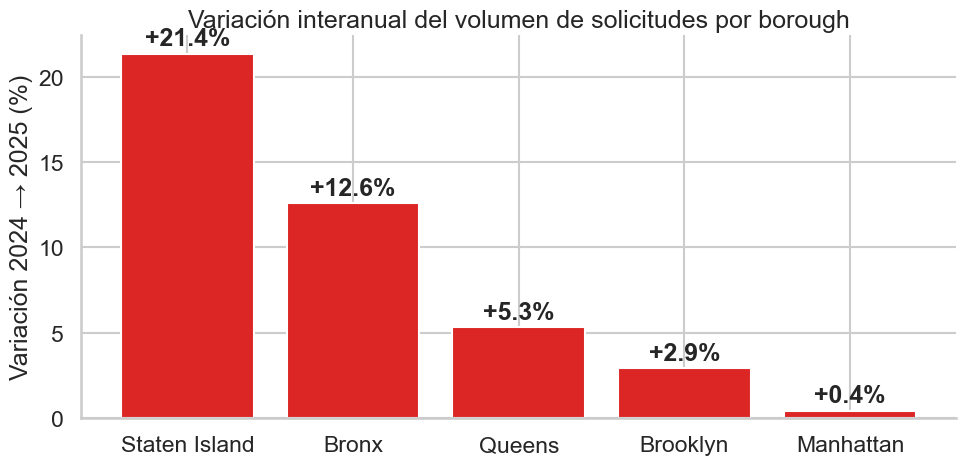

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#DC2626' if v >= 0 else '#2563EB' for v in metric_variacion_anual['variacion_pct']]
ax.bar(metric_variacion_anual['Borough'], metric_variacion_anual['variacion_pct'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel(f'Variación {ANIO_INICIO} → {ANIO_FIN} (%)')
ax.set_title('Variación interanual del volumen de solicitudes por borough')
for i, v in enumerate(metric_variacion_anual['variacion_pct']):
    ax.text(i, v + (0.5 if v >= 0 else -1.5), f'{v:+.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'variacion_anual_borough.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Validación

Antes de exportar, verificamos que el segmento sea una partición completa de `fact_periodo` (no pierde ni duplica solicitudes) y que las participaciones porcentuales sumen 100% por borough.

In [14]:
validation = pd.DataFrame([
    {'check': 'filas_fact_completo',            'value': len(fact)},
    {'check': 'filas_fact_periodo',             'value': len(fact_periodo)},
    {'check': 'rango_anios_analizado',          'value': f'{ANIO_INICIO}-{ANIO_FIN}'},
    {'check': 'filas_seg_familia_borough',      'value': len(seg_familia_borough)},
    {'check': 'boroughs_en_segmento',           'value': seg_familia_borough['Borough'].nunique()},
    {'check': 'familias_en_segmento',           'value': seg_familia_borough['problem_family'].nunique()},
    {'check': 'suma_n_segmento_vs_periodo_ok',  'value': bool(seg_familia_borough['n_solicitudes'].sum() == len(fact_periodo))},
    {'check': 'pct_share_suma_100_por_borough', 'value': bool(np.allclose(seg_familia_borough.groupby('Borough')['pct_share_borough'].sum(), 100, atol=0.1))},
    {'check': 'filas_metric_sla_resolucion',    'value': len(metric_sla_resolucion)},
    {'check': 'filas_metric_variacion_anual',   'value': len(metric_variacion_anual)},
])
print(validation.to_string(index=False))

assert seg_familia_borough['n_solicitudes'].sum() == len(fact_periodo), 'ERROR: el segmento no cubre todas las filas del periodo'
assert np.allclose(seg_familia_borough.groupby('Borough')['pct_share_borough'].sum(), 100, atol=0.1), 'ERROR: el % de participación no suma 100% por borough'

print('\n✓ Todos los checks de integridad pasados')

                         check     value
           filas_fact_completo     94500
            filas_fact_periodo     71064
         rango_anios_analizado 2024-2025
     filas_seg_familia_borough        50
          boroughs_en_segmento         5
          familias_en_segmento        10
 suma_n_segmento_vs_periodo_ok      True
pct_share_suma_100_por_borough      True
   filas_metric_sla_resolucion        10
  filas_metric_variacion_anual         5

✓ Todos los checks de integridad pasados


---
## 6. Exportación para Tableau

Exportamos el segmento, las dos métricas derivadas, los parámetros aplicados (para trazabilidad) y los checks de validación. Las imágenes (`heatmap_*.png`, `sla_*.png`, `variacion_*.png`) ya se guardaron en las celdas correspondientes.

**Convención**: todo va a `outputs/week-05-311/`, separado de `week-04-311/` (modelo estrella) — así Tableau puede conectar la fuente base sin que un re-cálculo de métricas la sobreescriba.

In [15]:
parametros_aplicados = pd.DataFrame([
    {'parametro': 'ANIO_INICIO', 'valor': ANIO_INICIO,
     'justificacion': '2023 es un año parcial (datos desde agosto); se excluye para no distorsionar comparaciones interanuales'},
    {'parametro': 'ANIO_FIN', 'valor': ANIO_FIN,
     'justificacion': '2026 es un año parcial (datos hasta abril); se excluye por el mismo motivo'},
    {'parametro': 'UMBRALES_SLA_HORAS', 'valor': str(UMBRALES_SLA_HORAS),
     'justificacion': '24h (1 día) y 72h (3 días) son referencias de servicio ciudadano habituales; reportar ambas evita un único umbral arbitrario'},
    {'parametro': 'POBLACION_BOROUGH', 'valor': 'Censo EE. UU. 2020',
     'justificacion': 'normaliza el volumen de solicitudes por habitante para comparar boroughs en igualdad de condiciones'},
])

exports = {
    'seg_familia_borough':      seg_familia_borough,
    'metric_familia_dominante': metric_familia_dominante,
    'metric_sla_resolucion':    metric_sla_resolucion,
    'metric_variacion_anual':   metric_variacion_anual,
    'parametros_aplicados':     parametros_aplicados,
    'validation_checks':        validation,
}

for name, table in exports.items():
    path = OUTPUT_DIR / f'{name}.csv'
    table.to_csv(path, index=False)
    print(f'✓ {name}.csv  →  {table.shape}  →  {path}')

# ── Copia consolidada para Tableau (outputs/tableau/) ───────────
# validation_checks es solo para auditoría del pipeline, no se conecta en Tableau
for name, table in exports.items():
    if name == 'validation_checks':
        continue
    path = save_for_tableau_final(table, name)
    print(f'✓ tableau/{name}.csv  →  {table.shape}  →  {path}')

✓ seg_familia_borough.csv  →  (50, 5)  →  C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-05-311\seg_familia_borough.csv
✓ metric_familia_dominante.csv  →  (5, 5)  →  C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-05-311\metric_familia_dominante.csv
✓ metric_sla_resolucion.csv  →  (10, 4)  →  C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-05-311\metric_sla_resolucion.csv
✓ metric_variacion_anual.csv  →  (5, 4)  →  C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-05-311\metric_variacion_anual.csv
✓ parametros_aplicados.csv  →  (4, 3)  →  C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-05-311\parametros_aplicados.csv
✓ validation_checks.csv  →  (10, 2)  →  C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-05-311\validation_checks.csv
✓ tableau/seg_familia_borough.csv  → 

---
## 7. Reflexión metodológica

### Resumen de lo construido en este notebook

| Elemento | Definición | Archivo exportado |
|---|---|---|
| Segmento | `problem_family` × `Borough`, con volumen, participación % y tasa por 10k habitantes | `seg_familia_borough.csv` |
| Métrica derivada 1 | Familia de problema dominante por borough (con y sin `'Otros'`) | `metric_familia_dominante.csv` |
| Métrica derivada 2 | % de solicitudes resueltas dentro de 24h / 72h por familia de problema | `metric_sla_resolucion.csv` |
| Métrica derivada 3 | Variación interanual (%) del volumen de solicitudes por borough, 2024→2025 | `metric_variacion_anual.csv` |
| Parámetro 1 | Rango de años de análisis (`ANIO_INICIO`/`ANIO_FIN`) — excluye años parciales | aplicado a todas las tablas anteriores |
| Parámetro 2 | Umbrales de cumplimiento de resolución (`UMBRALES_SLA_HORAS`) | usado en `metric_sla_resolucion.csv` |
| Referencia externa | Población por borough (Censo 2020) | usada en `seg_familia_borough.csv` |

El detalle de fórmulas, justificación de cada métrica/segmento/parámetro y alternativas descartadas vive en `docs/reglas-metricas-segmentos-parametros.md` — este notebook implementa esas reglas, no las redefine.

### Cómo conectar en Tableau

1. `fact_311.csv` y las dimensiones de `outputs/week-04-311/` siguen siendo la fuente principal (modelo estrella, sección 7 del notebook 03).
2. `seg_familia_borough.csv` se conecta como fuente independiente para el bloque de segmentación (mapa o treemap por borough, color por familia, tamaño por `pct_share_borough` o `tasa_por_10k_hab`).
3. `metric_sla_resolucion.csv` y `metric_variacion_anual.csv` alimentan vistas específicas (cumplimiento por familia, tendencia por borough) sin necesidad de campos calculados adicionales en Tableau.
4. `parametros_aplicados.csv` es documentación, no se visualiza — sirve para que cualquier persona que abra el workbook entienda qué alcance temporal y qué umbrales se usaron sin tener que leer el notebook.